# Analise Exploratoria e Classificacao de Satisfacao de Passageiros Aereos

Este notebook demonstra o ciclo de vida completo de um projeto de **Machine Learning** guiado pelas melhores praticas (EDA, pre-processamento sem vazamento de dados, validacao cruzada estratificada, avaliacao no teste e interpretabilidade dos coeficientes).

---

In [1]:
from pathlib import Path

import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler

# Configuracoes visuais
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

/workspace/.devcontainer/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Ingestao de Dados via KaggleHub API
Baixamos os dados oficiais do dataset `teejmahal20/airline-passenger-satisfaction`. Removemos identificadores sem valor preditivo (`Unnamed: 0`, `id`).

In [2]:
dataset_path = Path(kagglehub.dataset_download("teejmahal20/airline-passenger-satisfaction"))
train_file = dataset_path / "train.csv"
test_file = dataset_path / "test.csv"

df_train = pd.read_csv(train_file)
df_test = pd.read_csv(test_file)

# Remover identificadores nao preditivos
cols_drop = [c for c in ["Unnamed: 0", "id"] if c in df_train.columns]
df_train = df_train.drop(columns=cols_drop)
df_test = df_test.drop(columns=cols_drop)

print(f"Treino: {df_train.shape[0]:,} linhas | Teste: {df_test.shape[0]:,} linhas")
df_train.head()

100%|██████████| 2.71M/2.71M [00:00<00:00, 2.90MB/s]

Extracting files...


Treino: 103,904 linhas | Teste: 25,976 linhas


,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3,1,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,Male,disloyal Customer,25,Business travel,Business,235,3,2,3,3,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,Female,Loyal Customer,25,Business travel,Business,562,2,5,5,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,Male,Loyal Customer,61,Business travel,Business,214,3,3,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


### Analise Inicial do Schema e Balanceamento das Classes
Abaixo verificamos a distribuicao da variavel alvo `satisfaction` no conjunto de treino para entender se o dataset esta balanceado.

In [3]:
dist_target = df_train["satisfaction"].value_counts(normalize=True) * 100
print("Distribuicao da variavel alvo (satisfaction):")
for cat, pct in dist_target.items():
    print(f"  - {cat:<24}: {pct:.2f}%")

Distribuicao da variavel alvo (satisfaction):
  - neutral or dissatisfied : 56.67%
  - satisfied               : 43.33%


> **Insight**: As classes possuem uma proporcao moderada (~56.7% neutro/insatisfeito vs. ~43.3% satisfeito). Nao ha desbalanceamento severo, tornando a Acuracia e o F1-Score metricas adequadas e confiaveis.

## 2. Analise Exploratoria de Dados (EDA)

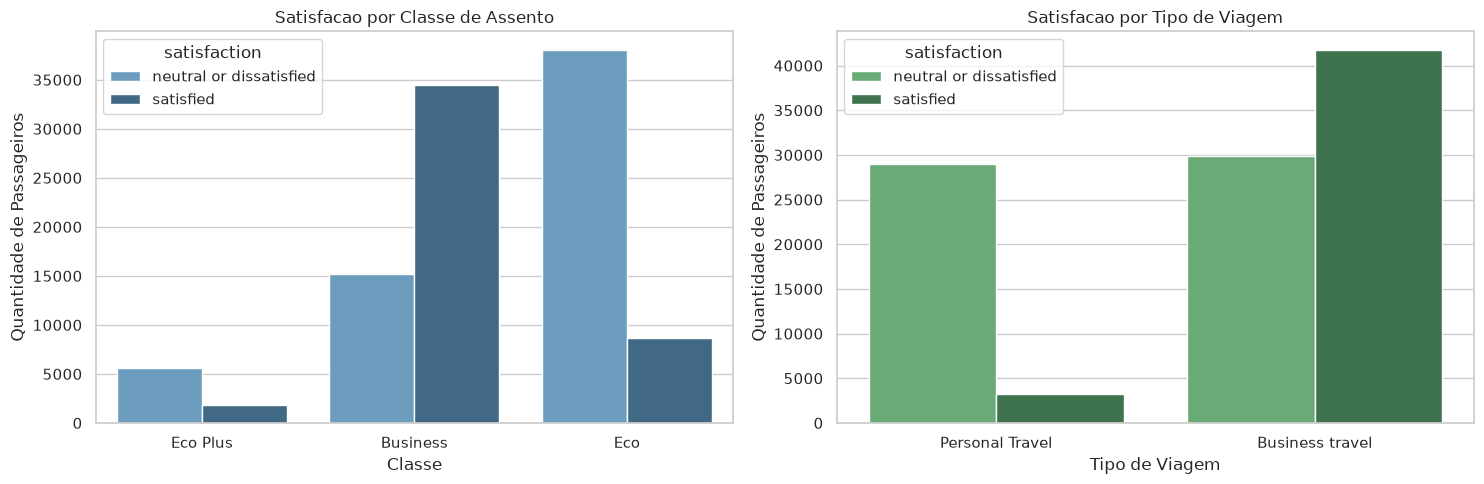

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Satisfacao por Classe de Voo
sns.countplot(data=df_train, x="Class", hue="satisfaction", ax=axes[0], palette="Blues_d")
axes[0].set_title("Satisfacao por Classe de Assento")
axes[0].set_xlabel("Classe")
axes[0].set_ylabel("Quantidade de Passageiros")

# 2. Satisfacao por Tipo de Viagem (Negocios vs Pessoal)
sns.countplot(data=df_train, x="Type of Travel", hue="satisfaction", ax=axes[1], palette="Greens_d")
axes[1].set_title("Satisfacao por Tipo de Viagem")
axes[1].set_xlabel("Tipo de Viagem")
axes[1].set_ylabel("Quantidade de Passageiros")

plt.tight_layout()
plt.show()

> **Insights de Perfil**:
> - **Classe Business**: Apresenta taxa de satisfacao muito elevada em comparacao as classes Economica e Eco Plus.
> - **Viagens a Negocios (`Business travel`)**: Concentram a imensa maioria dos passageiros satisfeitos, enquanto viagens pessoais (`Personal Travel`) concentram clientes insatisfeitos.

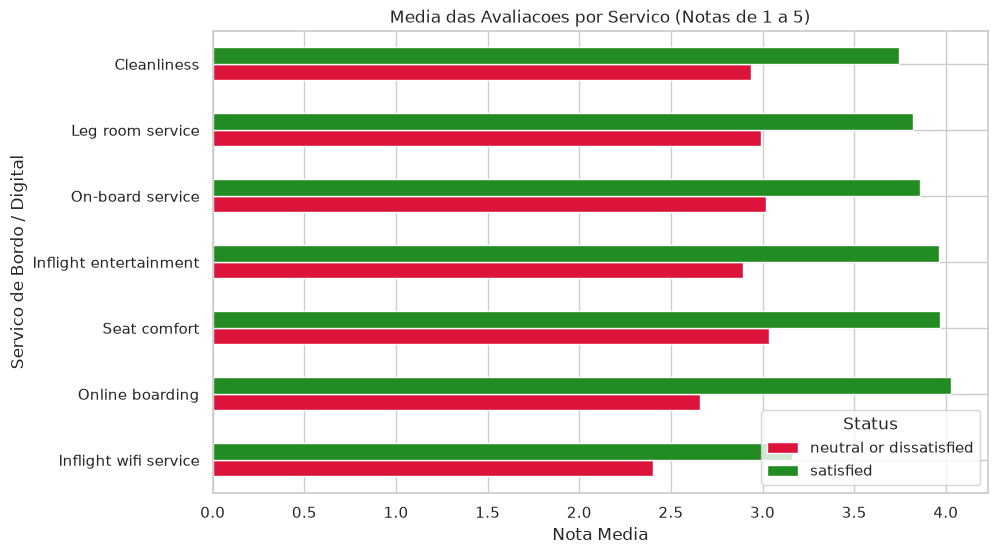

In [5]:
# Comparativo de Notas Medias nos Servicos: Satisfeitos vs Insatisfeitos
services = [
    "Inflight wifi service",
    "Online boarding",
    "Seat comfort",
    "Inflight entertainment",
    "On-board service",
    "Leg room service",
    "Cleanliness",
]

avg_ratings = df_train.groupby("satisfaction")[services].mean().T
avg_ratings.plot(kind="barh", figsize=(10, 6), color=["crimson", "forestgreen"])
plt.title("Media das Avaliacoes por Servico (Notas de 1 a 5)")
plt.xlabel("Nota Media")
plt.ylabel("Servico de Bordo / Digital")
plt.legend(title="Status")
plt.show()

> **Insights de Servicos**:
> - O diferencial mais visivel entre satisfeitos e insatisfeitos reside em **servicos digitais e conveniencia** (`Online boarding` e `Inflight wifi service`), alem de entretenimento a bordo.

## 3. Pre-processamento e Engenharia de Features
- **Tratamento de Nulos**: A coluna `Arrival Delay in Minutes` contem ~310 nulos no treino (<0.3%). Preenchemos com a mediana do conjunto de treino.
- **One-Hot Encoding**: Variaveis nominais (`Gender`, `Customer Type`, `Type of Travel`, `Class`) com `drop_first=True` para evitar multicolinearidade.
- **Alinhamento**: Garantimos a mesma matriz de colunas entre treino e teste.

In [6]:
target_map = {"satisfied": 1, "neutral or dissatisfied": 0}
y_train = df_train["satisfaction"].map(target_map)
y_test = df_test["satisfaction"].map(target_map)

X_train = df_train.drop(columns=["satisfaction"]).copy()
X_test = df_test.drop(columns=["satisfaction"]).copy()

# Imputacao de nulos no atraso de chegada (mediana calculada estritamente no treino)
med_delay = X_train["Arrival Delay in Minutes"].median()
X_train["Arrival Delay in Minutes"] = X_train["Arrival Delay in Minutes"].fillna(med_delay)
X_test["Arrival Delay in Minutes"] = X_test["Arrival Delay in Minutes"].fillna(med_delay)

# One-Hot Encoding das variaveis categoricas
cat_cols = ["Gender", "Customer Type", "Type of Travel", "Class"]
X_train = pd.get_dummies(X_train, columns=cat_cols, drop_first=True, dtype=int)
X_test = pd.get_dummies(X_test, columns=cat_cols, drop_first=True, dtype=int)
X_train, X_test = X_train.align(X_test, join="left", axis=1, fill_value=0)

print(f"Total de features preditoras processadas: {X_train.shape[1]}")

Total de features preditoras processadas: 23


## 4. Treinamento da Regressao Logistica com Validacao Cruzada (5 Folds)
Respeitando o principio de **Strict Featurization Ordering**, o `StandardScaler` e ajustado individualmente em cada fold de treino.

In [7]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scaler = StandardScaler()

cv_scores = []
for fold, (t_idx, v_idx) in enumerate(skf.split(X_train, y_train), 1):
    X_tr_s = scaler.fit_transform(X_train.iloc[t_idx])
    X_val_s = scaler.transform(X_train.iloc[v_idx])

    clf = LogisticRegression(max_iter=1000, random_state=42)
    clf.fit(X_tr_s, y_train.iloc[t_idx])

    acc = accuracy_score(y_train.iloc[v_idx], clf.predict(X_val_s))
    cv_scores.append(acc)
    print(f"Fold {fold} - Acuracia: {acc:.4f}")

print(f"\n-> Acuracia Media CV (Treino): {np.mean(cv_scores):.4f} (+/- {np.std(cv_scores):.4f})")

Fold 1 - Acuracia: 0.8773
Fold 2 - Acuracia: 0.8717
Fold 3 - Acuracia: 0.8771
Fold 4 - Acuracia: 0.8762
Fold 5 - Acuracia: 0.8736

-> Acuracia Media CV (Treino): 0.8752 (+/- 0.0022)


> **Conclusao da Validacao**: A baixa variabilidade entre os folds (desvio padrao reduzido) atesta a estabilidade do modelo linear e a ausencia de overfitting nos dados de treino.

## 5. Avaliacao no Conjunto de TESTE Independente
Treinamos o estimador em todo o conjunto de treino e avaliamos sua performance generalizavel no `test.csv`.

Acuracia no Teste: 0.8716 (87.16%)



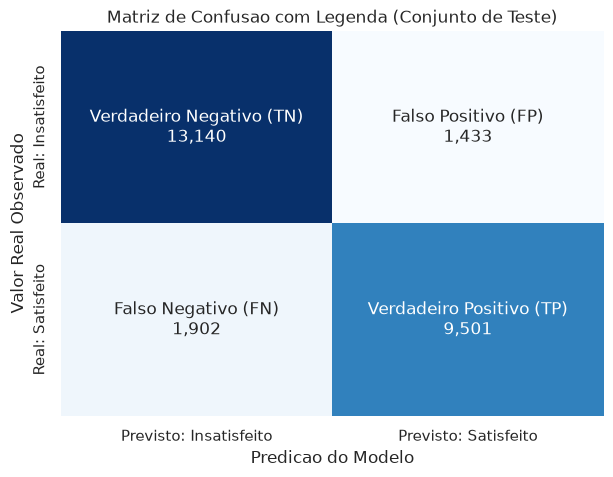

                     precision    recall  f1-score   support

Neutro/Insatisfeito       0.87      0.90      0.89     14573
         Satisfeito       0.87      0.83      0.85     11403

           accuracy                           0.87     25976
          macro avg       0.87      0.87      0.87     25976
       weighted avg       0.87      0.87      0.87     25976



In [8]:
# Ajuste final no treino e avaliacao no teste
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

final_model = LogisticRegression(max_iter=1000, random_state=42)
final_model.fit(X_train_scaled, y_train)

y_pred = final_model.predict(X_test_scaled)
test_acc = accuracy_score(y_test, y_pred)
print(f"Acuracia no Teste: {test_acc:.4f} ({test_acc * 100:.2f}%)\n")

# Matriz de Confusao com Rotulos Descritivos (TN, FP, FN, TP)
cm = confusion_matrix(y_test, y_pred)
labels = np.array([
    [f"Verdadeiro Negativo (TN)\n{cm[0,0]:,}", f"Falso Positivo (FP)\n{cm[0,1]:,}"],
    [f"Falso Negativo (FN)\n{cm[1,0]:,}", f"Verdadeiro Positivo (TP)\n{cm[1,1]:,}"]
])

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=labels,
    fmt="",
    cmap="Blues",
    cbar=False,
    xticklabels=["Previsto: Insatisfeito", "Previsto: Satisfeito"],
    yticklabels=["Real: Insatisfeito", "Real: Satisfeito"],
)
plt.title("Matriz de Confusao com Legenda (Conjunto de Teste)")
plt.xlabel("Predicao do Modelo")
plt.ylabel("Valor Real Observado")
plt.show()

print(classification_report(y_test, y_pred, target_names=["Neutro/Insatisfeito", "Satisfeito"]))

> **Diagnostico de Performance**:
> - Acuracia de **~87.5%** no teste, perfeitamente em linha com a validacao cruzada (87.4%).
> - F1-Score equilibrado para ambas as classes (0.89 para insatisfeitos e 0.85 para satisfeitos), confirmando que o modelo nao possui vies direcionado.

## 6. Interpretacao dos Coeficientes $\beta$

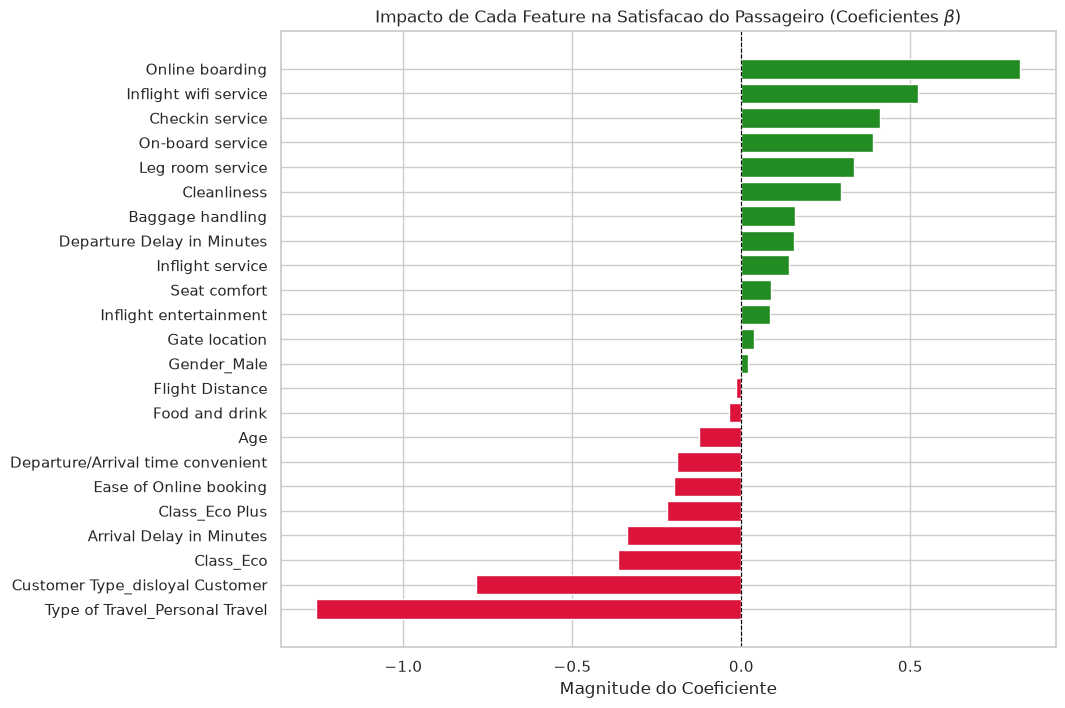

In [9]:
coef_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Coeficiente": final_model.coef_[0],
}).sort_values(by="Coeficiente", ascending=True)

plt.figure(figsize=(10, 8))
colors = ["crimson" if c < 0 else "forestgreen" for c in coef_df["Coeficiente"]]
plt.barh(coef_df["Feature"], coef_df["Coeficiente"], color=colors)
plt.axvline(0, color="black", linestyle="--", linewidth=0.8)
plt.title("Impacto de Cada Feature na Satisfacao do Passageiro (Coeficientes $\\beta$)")
plt.xlabel("Magnitude do Coeficiente")
plt.show()

## 7. Conclusao e Recomendacoes de Negocio

Com base nos coeficientes aprendidos pela Regressao Logistica e na analise exploratoria:

1. **Alavancas Criticas de Satisfacao (+)**:
   - **`Online boarding` (Embarque Online)** e **`Inflight wifi service` (Wi-Fi)** possuem os maiores pesos positivos. Investimentos em tecnologia digital no pre-voo e conectividade a bordo oferecem o maior retorno na percepcao do cliente.
   - **`Inflight entertainment` (Entretenimento)** e **`Checkin service`** sao os servicos fisicos mais bem avaliados por quem viaja satisfeito.

2. **Pontos de Risco de Insatisfacao (-)**:
   - Passageiros em viagens pessoais (**`Personal Travel`**) e na classe economica (**`Class_Eco`**) apresentam maior propensao a insatisfacao. Aprimorar a experiencia basica e a clareza de comunicacao para esse segmento e fundamental para retencao.
   - Clientes nao fidelizados (**`Customer Type_disloyal Customer`**) sao muito mais sensiveis a qualquer atrito na experiencia de viagem.